In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Flatten

from sklearn.metrics import accuracy_score

In [11]:
df = pd.read_csv('/content/housing.csv')

In [12]:
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


In [13]:
df.drop(columns=['ocean_proximity'], inplace=True)

In [14]:
x = df.drop(columns=['median_house_value'])
y = df['median_house_value']

In [15]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
scaler = StandardScaler()

In [18]:
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [23]:
model = Sequential()
model.add(Dense(10, activation='relu', input_dim=8))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 10)                  │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(loss='mean_squared_error', optimizer='Adam')

In [26]:
history = model.fit(x_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 55974690816.0000 - val_loss: 56854700032.0000
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 56049123328.0000 - val_loss: 56703696896.0000
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 56338157568.0000 - val_loss: 56300003328.0000
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 54773731328.0000 - val_loss: 55574683648.0000
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 54565384192.0000 - val_loss: 54510215168.0000
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 53110951936.0000 - val_loss: 53086584832.0000
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 51216584704.0000 - val_loss: 51320446976.0000
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 49853812736.0000 - val_loss: 49245376512.0000
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 48426573824.0000 - val_loss: 46893158400.0000
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2m

**With Feature Scaling**

Text(0.5, 0, 'Epoch')

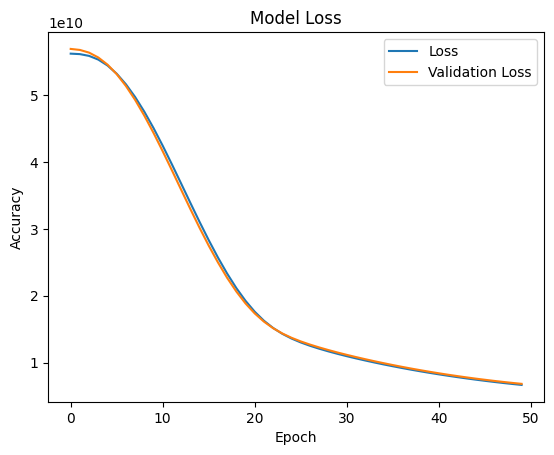

In [27]:
plt.plot(history.history['loss'], label = "Loss")
plt.plot(history.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

**Without Feature Scaling**

In [28]:
x = df.drop(columns=['median_house_value'])
y = df['median_house_value']

In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
model1 = Sequential()
model1.add(Dense(10, activation='relu', input_dim=8))
model1.add(Dense(10, activation='relu'))
model1.add(Dense(1, activation='linear'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [31]:
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 10)                  │              90 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

In [32]:
model1.compile(loss='mean_squared_error', optimizer='Adam')

In [33]:
history1 = model1.fit(x_train, y_train, epochs=50, validation_split=0.2)

Epoch 1/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 55536680960.0000 - val_loss: 44250316800.0000
Epoch 2/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 36704034816.0000 - val_loss: 27947268096.0000
Epoch 3/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 26555561984.0000 - val_loss: 27583965184.0000
Epoch 4/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 26051346432.0000 - val_loss: 27277619200.0000
Epoch 5/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 26039050240.0000 - val_loss: 26956994560.0000
Epoch 6/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 25191071744.0000 - val_loss: 26595577856.0000
Epoch 7/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 26237839360.0000 - val_loss: 26256988160.0000
Epoch 8/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 26490632192.0000 - val_loss: 25810616320.0000
Epoch 9/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 24382394368.0000 - val_loss: 25123106816.0000
Epoch 10/50
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 2m

Text(0.5, 0, 'Epoch')

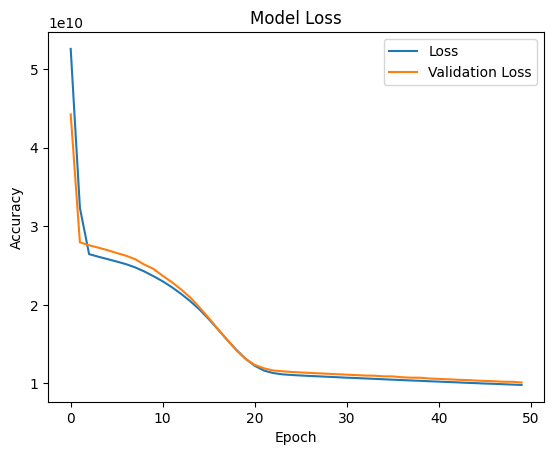

In [35]:
plt.plot(history1.history['loss'], label = "Loss")
plt.plot(history1.history['val_loss'], label = "Validation Loss")

plt.legend()
plt.title('Model Loss')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')